# DPAC Clustering

Logan Wong

law3082

Load the embeddings

DPAC did pretraining to learn features from images.
But I'm not using images, I'm using Tweets.
The Tweets were embedded into vectors using a pretrained LLM, all-mpnet-base-v2, which follows the SBERT architecture.

Do clustering using DPAC

Neither paper split their data into train/valid/test
So neither paper did hyperparameter tuning.

But, the DPAC paper had these hyperparameters:
Weight exponent, m: 1.03
Temperature, tau: 0.5
Adam Optimizer LR: 0.0001
1000 epochs for the pre-training step
200 epochs for the clustering step
Cluster number, K: predefined for the algorithms…

Incremental Clustering for Event Detection on Twitter paper had a dynamic incremental learning algo that did NOT need T, the # of clusters, predefined.

DPAC DID need K, the # of clusters, to be predefined.

In [1]:
import sys
import os

# Add the DPAC program folder to path
dpac_path = '/home/stu5/s5/law3082/Courses/MLDD/Deep-Probability-Aggregation-Clustering/PAC_DPAC_program/'
if dpac_path not in sys.path:
    sys.path.append(dpac_path)

In [2]:
import pandas as pd
import time

import argparse
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from models import Network 
from contrastive_loss import InfonceLoss
import torch.nn.functional as F

import matplotlib.pyplot as plt

# Evaluation metrics
# from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.metrics.cluster import adjusted_mutual_info_score, adjusted_rand_score


In [3]:
os.environ["CUDA_VISIBLE_DEVICES"]="6"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
def convert(seconds):
    seconds = seconds % (24 * 3600)
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60

    return "%d:%02d:%02d" % (hour, minutes, seconds)

# Load Embeddings

In [5]:
embeddings_raw = np.load('data/event2012_embeddings.npy')
# Convert to a Float Tensor & move to GPU
embeddings = torch.from_numpy(embeddings_raw).float().to(device)

# Load the metadata to track tweet IDs
metadata = pd.read_csv('data/event2012_metadata.csv')

print(f"Loaded {embeddings.shape[0]} embeddings with dimension {embeddings.shape[1]}")

Loaded 68841 embeddings with dimension 768


In [6]:
# This class is based on ContrastiveLearningDataset, found in 
# /Courses/MLDD/Deep-Probability-Aggregation-Clustering/PAC_DPAC_program/data/
class TwitterVectorDataset(Dataset):
    def __init__(self, vecs):
        self.vecs = vecs
        
    def __len__(self):
        return len(self.vecs)

    def __getitem__(self, idx):
        x = self.vecs[idx]
        # DPAC expects (weak, strong, ori). 
        # "views" are simulated by adding 1% and 5% noise to the vectors.
        weak = x + torch.randn_like(x) * 0.01
        strong = x + torch.randn_like(x) * 0.05
        return (weak, strong, x), 0 # 0 is a placeholder label

In [7]:
# Initialize loader
dataset = TwitterVectorDataset(embeddings)
batch_size = 256
ins_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# a mismatch between batch size and the number of tweets in the dataset
# total number of tweets isn't perfectly divisible by 256, the very last batch is smaller (a "partial batch")
# tell DataLoader to ignore the last tiny leftover piece of data
# DataLoader drops the "partial batch" 

In [8]:
# Define a Backbone for vectors
# original DPAC repo uses ResNet (which is for images)
# This is an MLP backbone to handle Twitter vectors
class TwitterBackbone(nn.Module):
    def __init__(self, input_dim=768, rep_dim=128):
        super().__init__()
        self.rep_dim = rep_dim # The Network class NEEDS this attribute
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, rep_dim)
        )
        
    def forward(self, x):
        return self.encoder(x)

In [9]:
input_dim = embeddings.shape[1]        # 768
# DPAC 'z' space dimension
feature_dim = 128               
my_backbone = TwitterBackbone(input_dim=input_dim, rep_dim=feature_dim)

# target number of clusters (events) aka class_num
num_events = 503
# Wrap backbone in the DPAC Network class and move to GPU
model = Network(my_backbone, my_backbone.rep_dim, class_dim=num_events).to(device)

print(f"Model initialized on {device} with input dimension {input_dim}")

Model initialized on cuda with input dimension 768


In [10]:
print(model.cluster_head)

Sequential(
  (0): Linear(in_features=128, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=503, bias=True)
)


In [11]:
# Original DPAC paper: Config 0
# hps = {
#     "weight_exponent_m": 1.03,
#     "lr":0.0001,
#     "weight_decay":0.0001,
#     "temp":0.5,
#     "epochs": 200,
#     "K": num_events
# }

# Config 1
# hps = {
#     "weight_exponent_m": 1.01,
#     "lr":0.0001,
#     "weight_decay":0.0001,
#     "temp":0.1,
#     "epochs": 200,
#     "K": num_events
# }

# Config 2
# hps = {
#     "weight_exponent_m": 1.05,
#     "lr":0.0001,
#     "weight_decay":0.0001,
#     "temp":0.7,
#     "epochs": 200,
#     "K": num_events
# }



hps = {
    "weight_exponent_m": 1.03,
    "lr":0.0001,
    "weight_decay":0.0001,
    "temp": 0.5,
    "epochs": 125,    # Loss curves show it plateaus at around 100-125 
    "K": num_events
}

In [12]:
# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=hps['lr'], weight_decay=hps['weight_decay'])

# Define Contrastive Loss (InfoNCE)
criterion = InfonceLoss(batch_size=batch_size, temperature=hps['temp'], device=device).to(device)

# Setup the GradScaler for mixed-precision training
scaler = torch.cuda.amp.GradScaler()

print(f"Optimizer and Criterion ready on {device}")

Optimizer and Criterion ready on cuda


/tmp/ipykernel_1252413/1930107486.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


# Training

In [13]:
def train_model(model, ins_loader, optimizer, criterion, scaler, device, m):
    model.train()
    loss_epoch = {'loss1': 0, 'loss2': 0}
    
    for step, ((weak, strong, ori), _) in enumerate(ins_loader):
        # Move all versions of the tweet vector to the GPU
        weak = weak.to(device)
        strong = strong.to(device)
        ori = ori.to(device)
        
        # Concatenate weak and strong for contrastive learning
        img = torch.cat((weak, strong), dim=0)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            # Forward pass
            z, p1, _ = model(img)
            
            # DPAC Clustering logic (Probability Aggregation)
            # Generate target distribution 'q'
            q, p = model.PAC_online(ori, m=m) 

            # model's last layer is a Linear layer, NOT softmax
            # THUS, convert raw logits (p1) into log-probabilities
            log_p1 = F.log_softmax(p1, dim=1)
            
            # Calculate Loss
            loss1 = criterion(z)         # Contrastive Loss (keeps tweets together)
            # loss2 = kldiv(q, p1)         # Clustering Loss (pushes tweets into events)
            loss2 = F.kl_div(log_p1, q, reduction='batchmean')
            
            loss = loss1 + loss2

        # Backprop
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        loss_epoch['loss1'] += loss1.item() / len(ins_loader)
        loss_epoch['loss2'] += loss2.item() / len(ins_loader)
        
    return loss_epoch

In [14]:
# Train and Save the model
history = {
    'contrastive': [],
    'clustering': []
}


# filename should include m, LR, weight decay, and temp
m_str = str(hps["weight_exponent_m"]).replace('.', '_')
lr_str = str(hps["lr"]).replace('.', '_')
wd_str = str(hps["weight_decay"]).replace('.', '_')
temp_str = str(hps["temp"]).replace('.', '_')
model_save_path = f'models/event2012_DPAC_m_{m_str}_lr_{lr_str}_wd_{wd_str}_temp{temp_str}.tar'
# model_save_path = 'models/event2012_DPAC_model_traind_on_all_data.tar'

epochs = hps["epochs"]
print("Training started")
start_time = time.time()
for epoch in tqdm(range(epochs)):
    # Run 1 full pass thru Twitter data
    losses = train_model(model, ins_loader, optimizer, criterion, scaler, device, m=hps["weight_exponent_m"])
    history['contrastive'].append(losses['loss1'])
    history['clustering'].append(losses['loss2'])
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Contrastive Loss: {losses['loss1']:.4f} | "
              f"Clustering Loss: {losses['loss2']:.4f}")
        
    # Save model weights
    if (epoch + 1) % 50 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': losses,
        }, f"checkpoints/checkpoint_epoch_{epoch+1}.tar")

end_time = time.time()
print("DONE!!!")
training_duration = end_time - start_time
time_in_minutes_and_seconds = convert(training_duration)

Training started


  5%|█████▎                                                                                                     | 10/200 [01:42<32:09, 10.15s/it]

Epoch [10/200] | Contrastive Loss: 4.4341 | Clustering Loss: 1.6804


 10%|██████████▋                                                                                                | 20/200 [03:25<31:30, 10.50s/it]

Epoch [20/200] | Contrastive Loss: 4.4034 | Clustering Loss: 1.8702


...

Epoch [180/200] | Contrastive Loss: 4.3331 | Clustering Loss: 2.2723


 95%|████████████████████████████████████████████████████████████████████████████████████████████████████▋     | 190/200 [31:48<01:39,  9.96s/it]

Epoch [190/200] | Contrastive Loss: 4.3314 | Clustering Loss: 2.2520


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [33:26<00:00, 10.03s/it]

Epoch [200/200] | Contrastive Loss: 4.3302 | Clustering Loss: 2.2685
DONE!!!


In [15]:
print(f"Time taken: {time_in_minutes_and_seconds}")
# Time taken: 0:36:46

Time taken: 0:33:26


In [16]:
# Save the state_dict and hyperparameters
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'hps': hps,
    'num_events': num_events
}, model_save_path)

print(f"Model saved successfully to {model_save_path}")

Model saved successfully to models/event2012_DPAC_m_1.03_lr_0_0001_wd_0_0001_temp0_5.tar


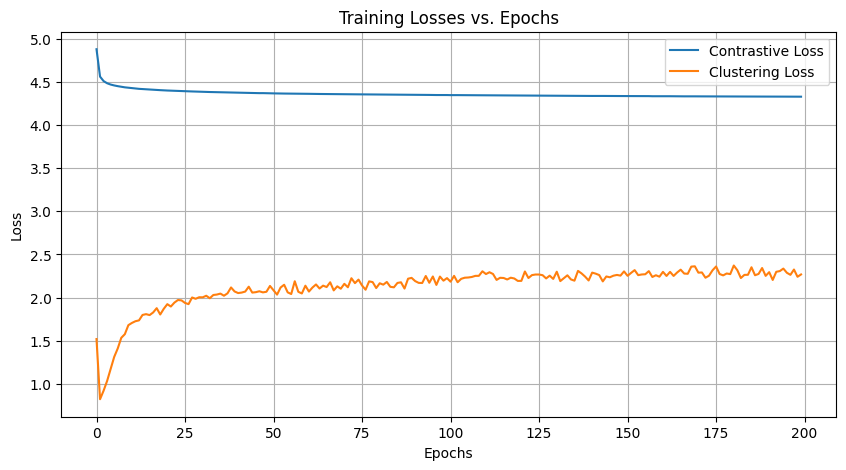

In [17]:
# Plot losses
plot_save_path = f'plots/loss_curves_m{m_str}_lr{lr_str}_wd{wd_str}_temp{temp_str}.png'

plt.figure(figsize=(10, 5))
plt.plot(history['contrastive'], label='Contrastive Loss')
plt.plot(history['clustering'], label='Clustering Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses vs. Epochs')
plt.legend()
plt.grid(True)

plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
plt.show()

# Evaluation

In [22]:
# Inference (No gradients needed)
model.eval()
with torch.no_grad():
    # test_forward returns (features, probabilities)
    _, probs = model.test_forward(embeddings)
    
    # Get cluster index with highest probability
    preds = torch.argmax(probs, dim=1).cpu().numpy()

# Get ground truth labels from metadata
y_true = metadata['label'].values

print(f"Clustering finished for {len(preds)} tweets.")

Clustering finished for 68841 tweets.


In [24]:
# Calculate Metrics
ari = adjusted_rand_score(y_true, preds)
ami = adjusted_mutual_info_score(y_true, preds)

print(f"ARI (Adjusted Rand Index): {ari:.4f}")
print(f"AMI (Adjusted Mutual Information): {ami:.4f}")

# BASELINE:
# ARI: 0.63
# AMI: 0.86

# ARI measures how many pairs of tweets are correctly grouped together or correctly separated. 
# AMI measures how much info is shared between my clusters and the true events. 

# Config 0 results:
# ARI (Adjusted Rand Index): 0.1594
# AMI (Adjusted Mutual Information): 0.6632

# Config 1 results
# ARI (Adjusted Rand Index): 0.0898
# AMI (Adjusted Mutual Information): 0.5062


# Config 2 results:
# ARI (Adjusted Rand Index): 0.1569
# AMI (Adjusted Mutual Information): 0.6536

ARI (Adjusted Rand Index): 0.1594
AMI (Adjusted Mutual Information): 0.6632


In [20]:
# parser = argparse.ArgumentParser()
# parser.add_argument('-dataset-name', default='cifar10',
#                     help='dataset name',
#                     choices=['stl10', 'cifar10', 'cifar100', 'imagenet10', 'imagenet_dogs', 'tiny_imagenet'])
# parser.add_argument('-data', metavar='DIR', default='./datasets',
#                     help='path to dataset')
# parser.add_argument('-model-path', default='./save/CIFAR-10',
#                     help='path to save model')
# # Training Hyper parameter
# parser.add_argument('--epochs', default=200, type=int, metavar='N',
#                     help='number of total epochs to run')
# parser.add_argument('-b', '--batch-size', default=256, type=int,
#                     metavar='N',
#                     help='mini-batch size (default: 240), this is the total '
#                          'batch size of all GPUs on the current node when '
#                          'using Data Parallel or Distributed Data Parallel')
# parser.add_argument('--lr', '--learning-rate', default=1e-4, type=float,
#                     metavar='LR', help='initial learning rate', dest='lr')
# parser.add_argument('--wd', '--weight-decay', default=1e-4, type=float,
#                     metavar='W', help='weight decay (default: 1e-4)',
#                     dest='weight_decay')
# parser.add_argument('--resnet', default='ResNet34', help='Choice resnet.')

# # Hyper parameter
# parser.add_argument('--temperature', default=0.5, type=float, help='softmax temperature (default: 0.5)')
# parser.add_argument('--m', default=1.03, type=float, help='weight exponent > 1 (default: 1.03)')
# parser.add_argument('--thd', default=0.99, type=float, help='threshold of pseudo label (default: 0.95)')

# # Deployment
# parser.add_argument('--gpu-index', default=0, type=int, help='Gpu index.')
# parser.add_argument('--seed', default=0, type=int)


# # NEW!!! I ADDED THIS!!!
# def kldiv(q, p):
#     """
#     Standard KL Divergence for clustering.
#     q: Target distribution (sharpened)
#     p: Predicted distribution
#     """
#     res = -torch.sum(q * torch.log(p + 1e-8), dim=-1)
#     return res.mean()
    

# def pac_loss(p, f):
#     N, C = p.shape
#     p = F.softmax(p, dim=1)
#     dis = 1 - 1 * torch.matmul(f, f.T)
#     ps = torch.mm(p, p.T)
#     loss = (dis * ps).sum(1)
#     return loss.sum() / N


# def model(args, ins_loader, optimizer, criterion, model, scaler):
#     loss_epoch = {'loss1': 0, 'loss2': 0, 'loss3': 0}
#     for step, ((weak, strong, ori), _) in enumerate(ins_loader):
#         weak = weak.to(args.device)
#         strong = strong.to(args.device)
#         img = torch.cat((weak, strong), dim=0)
#         ori = ori.to(args.device)
#         optimizer.zero_grad()
#         with torch.cuda.amp.autocast():
#             z, p1, u2 = model(img)
#             q, p = model.PAC_online(ori, m=args.m)  # clustering codes
#             # loss1 = criterion(z, p)  # contrastive learning
#             loss1 = criterion(z)
#             loss2 = kldiv(q, p1)  # online clustering
#             """ self-labeling fine-tuning same as Fixmatch"""
#             # max_probs, tragets_p = torch.max(F.softmax(p1, dim=1), dim=-1)  # pseudo labels
#             # mask = max_probs.ge(args.thd).float()
#             # loss3 = (F.cross_entropy(u2, tragets_p, reduction='none') * mask).mean()  # self-labeling
#             loss = loss1 + loss2
#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()
#         loss_epoch['loss1'] += loss1.item() / len(ins_loader)
#         loss_epoch['loss2'] += loss2.item() / len(ins_loader)
#         # loss_epoch['loss3'] += loss3.item() / len(ins_loader)
#     return model, loss_epoch


# def main():
#     """ DPAC """
#     args = parser.parse_args()
#     args.device = torch.device(f'cuda:{args.gpu_index}')
#     torch.cuda.set_device(args.gpu_index)
#     print(f'select device:cuda{args.gpu_index}')
#     torch.manual_seed(args.seed)
#     torch.cuda.manual_seed_all(args.seed)
#     torch.cuda.manual_seed(args.seed)
#     np.random.seed(args.seed)

#     dataset = ContrastiveLearningDataset(args.data)
#     ins_dataset, class_num = dataset.get_dataset(args.dataset_name, dataset=True)
#     ins_loader = DataLoader(ins_dataset, batch_size=args.batch_size, shuffle=True, pin_memory=True,
#                                   num_workers=4, drop_last=True)
#     if args.dataset_name == 'cifar10' or args.dataset_name == 'cifar100':
#         res = get_resnet_cifar(args.resnet)
#     elif args.dataset_name == 'stl10':
#         res = get_resnet_stl(args.resnet)
#     else:
#         res = get_resnet(args.resnet)
#     model = Network(res, res.rep_dim, class_num)
#     model = model.to(args.device)
#     checkpoint = torch.load('./save/CL_1000.tar', map_location=args.device)
#     model.load_state_dict(checkpoint['net'], strict=False)
#     optimizer = torch.optim.Adam(model.parameters(), 1e-4, weight_decay=1e-4)
#     criterion = InfonceLoss(args.batch_size, args.temperature, args.device).to(args.device)
#     torch.backends.cudnn.benchmark = True
#     torch.backends.cuda.matmul.allow_tf32 = True
#     torch.backends.cudnn.allow_tf32 = True
#     scaler = torch.cuda.amp.GradScaler()

#     for epoch_counter in tqdm(range(args.epochs)):
#         model, loss_epoch = model(args, ins_loader, optimizer, criterion, model, scaler)
#         print(
#             f"Epoch [{epoch_counter}/{args.epochs}]\t "
#             f"loss1_epoch: {loss_epoch['loss1']}\t "
#             f"loss2_epoch: {loss_epoch['loss2']}\t "
#             f"loss3_epoch: {loss_epoch['loss3']}\t "
#         )
#         save_model(args, model, optimizer)


# if __name__ == '__main__':
#     main()
